In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit
import scipy.constants as spc
header = "C:/Users/qipe/Documents/K_Sunada/result/CDK184/"


In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [4]:
def Lorentzian(freq, amp, const, center, k):
    return const + amp*k**2/((freq-center)**2 + k**2)

In [5]:
data = "/2025-08-12/2025-08-12T083525_db4f2035-b00_spectrum"
dd_tx = datadict_from_hdf5(header + data +"/data")
ed = 0#1e-9/9/(10.25-10)

freq_tx = dd_tx['probe_frequency']['values']*1e9
# s11_eg = dd['s11_eg']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_g = dd_tx['s11_g']['values']* np.exp(1j*(ed*2*np.pi*freq_tx))
s11_e = dd_tx['s11_e']['values']* np.exp(1j*(ed*2*np.pi*freq_tx))
s11_eg_div_tx = s11_e / s11_g

data = "/2025-08-12/2025-08-12T083656_1167cc1c-b00_spectrum"
dd_rx = datadict_from_hdf5(header + data +"/data")
ed = 0#1e-9/9/(10.25-10)

freq_rx = dd_rx['probe_frequency']['values']*1e9
# s11_eg = dd['s11_eg']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_g = dd_rx['s11_g']['values']* np.exp(1j*(ed*2*np.pi*freq_rx))
s11_e = dd_rx['s11_e']['values']* np.exp(1j*(ed*2*np.pi*freq_rx))
s11_eg_div_rx = s11_e / s11_g

In [6]:
def s11_ge_dp(f, f_r, f_f, k_ex, k_in, chi, g, gamma, phi):
    k_tot = k_ex + k_in
    s11_g = np.cos(phi) + np.exp(1j*phi) * k_ex * (1j*(f-f_r) - gamma/2)/((1j*(f-f_f)-k_tot/2) * (1j*(f-f_r)-gamma/2) + g**2)
    s11_e = np.cos(phi) + np.exp(1j*phi) * k_ex * (1j*(f-(f_r+chi)) - gamma/2)/((1j*(f-f_f)-k_tot/2) * (1j*(f-(f_r+chi))-gamma/2) + g**2)
    return (s11_e/s11_g).conj()
def s11_ge(f, f_r, k_ex, k_in, chi, phi, a0):
    s11_g = np.cos(phi) + np.exp(1j*phi) *(1j*(f-f_r)+(k_ex-k_in)/2)/(1j*(f-f_r)-(k_ex+k_in)/2)
    s11_e = np.cos(phi) + np.exp(1j*phi) *(1j*(f-(f_r+chi))+(k_ex-k_in)/2)/(1j*(f-(f_r+chi))-(k_ex+k_in)/2)
    return (s11_e/s11_g).conj() + a0

def guess_params(data,x):
    par_ini = {"f_r":9.343e9, "k_ex": 10e6, "k_in":10e6, "chi":-5e6, "phi":np.pi/2, "a0":3,}
    par_max = {"f_r":np.inf, "k_ex":np.inf, "k_in":np.inf, "chi":0, "phi":np.pi,"a0":np.inf,}
    par_min = {"f_r":0, "k_ex":0, "k_in":0e-3, "chi":-np.inf,"phi":-np.pi,"a0":-np.inf,}
    par_vary = {"f_r":1,"k_ex":1, "k_in":1, "chi":1, "phi":0, "a0":1,}
    return par_ini,par_max,par_min,par_vary
def guess_params_dp(data,x):
    par_ini = {"f_r":9.346e9, "f_f":9.340e9, "k_ex": 138e6, "k_in":1e6, "chi":-5e6, "g":64e6, "gamma":0, "phi":0,}
    par_max = {"f_r":np.inf, "f_f":np.inf, "k_ex":np.inf, "k_in":np.inf, "chi":0, "g":np.inf, "gamma":np.inf, "phi":np.pi,}
    par_min = {"f_r":0, "f_f":0, "k_ex":0, "k_in":0e-3, "chi":-np.inf, "g":0, "gamma":0, "phi":-np.pi,}
    par_vary = {"f_r":1, "f_f":1, "k_ex":1, "k_in":0, "chi":1, "g":1, "gamma":0, "phi":0}
    return par_ini,par_max,par_min,par_vary

def probe_resonator_fit(data, x):
    import lmfit as lmf
    model = lmf.Model(s11_ge, nan_policy='omit')
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params(data,x)
    for name in params:
        params[name].set(
            value=par_ini[name],  # ???
            min=par_min[name],  # ???
            max=par_max[name],  # ???
            vary=par_vary[name] # ?????????????
        )
    result=model.fit(data, f=x, params=params, method='leastsq')
    return result
def probe_resonator_fit_dp(data, x):
    import lmfit as lmf
    model = lmf.Model(s11_ge_dp, nan_policy='omit')
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params_dp(data,x)
    for name in params:
        params[name].set(
            value=par_ini[name],  # ???
            min=par_min[name],  # ???
            max=par_max[name],  # ???
            vary=par_vary[name] # ?????????????
        )
    result=model.fit(data, f=x, params=params, method='leastsq')
    return result

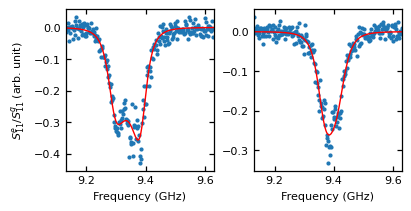

In [8]:
# result = probe_resonator_fit(s11_eg_div, freq)
result_tx = probe_resonator_fit_dp(s11_eg_div_tx, freq_tx)
result_rx = probe_resonator_fit_dp(s11_eg_div_rx, freq_rx)

fig, ax = plt.subplots(1, 2, figsize=(4,2), constrained_layout=True)

# plt.title("g-e transition")
ax[0].tick_params(axis="both", direction="in")
ax[0].tick_params(top=True, bottom=True, left=True, right=True)
ax[1].tick_params(axis="both", direction="in")
ax[1].tick_params(top=True, bottom=True, left=True, right=True)
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
# result.plot_fit(ax = ax)
ax[0].plot(freq_tx*1e-9, np.angle(s11_eg_div_tx), 'o')
ax[0].plot(freq_tx*1e-9, np.angle(result_tx.best_fit), c="red", lw=1.0)
ax[0].set_xlabel("Frequency (GHz)")
ax[0].set_ylabel(r"$S_{11}^e/S_{11}^g$ (arb. unit)")
ax[0].set_xlim(freq_tx[0]*1e-9, freq_tx[-1]*1e-9)

ax[1].plot(freq_rx*1e-9, np.angle(s11_eg_div_rx), 'o')
ax[1].plot(freq_rx*1e-9, np.angle(result_rx.best_fit), c="red", lw=1.0)
ax[1].set_xlabel("Frequency (GHz)")
ax[1].set_xlim(freq_tx[0]*1e-9, freq_tx[-1]*1e-9)
# plt.plot(freq, np.angle(result.init_fit))
# plt.xlim(9.365e9, 9.375e9)
# plt.ylim(-0.45, 0.25)
plt.savefig("mas_figs/chi_photon.pdf",  bbox_inches="tight")
plt.show()

result_tx
result_rx

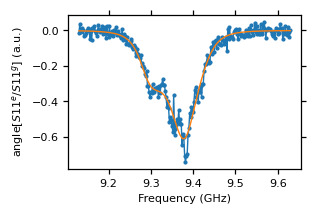

In [29]:
fig, ax = plt.subplots(figsize=(3, 2))
plt.plot(freq_rx*1e-9, np.angle(s11_eg_div_tx*s11_eg_div_rx), marker='o')
plt.plot(freq_rx*1e-9, np.angle(result_tx.best_fit*result_rx.best_fit))
plt.xlabel("Frequency (GHz)")
plt.ylabel(rf"angle[$S11^e/S11^g$] (a.u.)")
plt.show()

In [9]:
data = "/2025-08-11/2025-08-11T144757_bbcaab25-b00_spectrum"
dd_tx = datadict_from_hdf5(header + data +"/data")
ed = 0#1e-9/9/(10.25-10)

freq_tx = dd_tx['probe_frequency']['values']*1e9
# s11_eg = dd['s11_eg']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_g = dd_tx['s11_g']['values']* np.exp(1j*(ed*2*np.pi*freq_tx))
s11_e = dd_tx['s11_e']['values']* np.exp(1j*(ed*2*np.pi*freq_tx))
s11_eg_div_tx = s11_e / s11_g

data = "/2025-08-11/2025-08-11T224630_9619bb96-b00_spectrum"
dd_rx = datadict_from_hdf5(header + data +"/data")
ed = 0#1e-9/9/(10.25-10)

freq_rx = dd_rx['probe_frequency']['values']*1e9
# s11_eg = dd['s11_eg']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_g = dd_rx['s11_g']['values']* np.exp(1j*(ed*2*np.pi*freq_rx))
s11_e = dd_rx['s11_e']['values']* np.exp(1j*(ed*2*np.pi*freq_rx))
s11_eg_div_rx = s11_e / s11_g

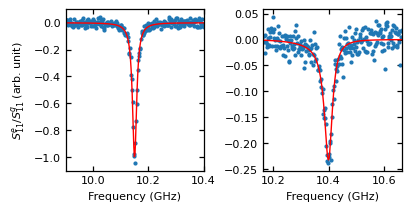

In [11]:
# result = probe_resonator_fit(s11_eg_div, freq)
def guess_params_dp(data,x):
    par_ini = {"f_r":10.148e9, "f_f":10.138e9, "k_ex": 33e6, "k_in":1e6, "chi":-4.3e6, "g":43e6, "gamma":0, "phi":0,}
    par_max = {"f_r":np.inf, "f_f":np.inf, "k_ex":np.inf, "k_in":np.inf, "chi":0, "g":np.inf, "gamma":np.inf, "phi":np.pi,}
    par_min = {"f_r":0, "f_f":0, "k_ex":0, "k_in":0e-3, "chi":-np.inf, "g":0, "gamma":0, "phi":-np.pi,}
    par_vary = {"f_r":1, "f_f":0, "k_ex":1, "k_in":1, "chi":1, "g":1, "gamma":0, "phi":0}
    return par_ini,par_max,par_min,par_vary
result_tx = probe_resonator_fit_dp(s11_eg_div_tx, freq_tx)
def guess_params_dp(data,x):
    par_ini = {"f_r":10.414e9, "f_f":10.405e9, "k_ex":38e6, "k_in":0.002e9, "chi":-6.5e6, "g":45e6, "gamma":0, "phi":-0.01,}
    par_max = {"f_r":np.inf, "f_f":np.inf, "k_ex":np.inf, "k_in":np.inf, "chi":0, "g":np.inf, "gamma":np.inf, "phi":np.pi,}
    par_min = {"f_r":0, "f_f":0, "k_ex":0, "k_in":0e-3, "chi":-np.inf, "g":0, "gamma":0, "phi":-np.pi,}
    par_vary = {"f_r":1, "f_f":1, "k_ex":1, "k_in":0, "chi":1, "g":1, "gamma":0, "phi":0}
    return par_ini,par_max,par_min,par_vary
result_rx = probe_resonator_fit_dp(1/s11_eg_div_rx, freq_rx)

fig, ax = plt.subplots(1, 2, figsize=(4,2), constrained_layout=True)

# plt.title("g-e transition")
ax[0].tick_params(axis="both", direction="in")
ax[0].tick_params(top=True, bottom=True, left=True, right=True)
ax[1].tick_params(axis="both", direction="in")
ax[1].tick_params(top=True, bottom=True, left=True, right=True)
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
# result.plot_fit(ax = ax)
ax[0].plot(freq_tx*1e-9, np.angle(s11_eg_div_tx), 'o')
ax[0].plot(freq_tx*1e-9, np.angle(result_tx.best_fit), c="red", lw=1.0)
ax[0].set_xlabel("Frequency (GHz)")
ax[0].set_ylabel(r"$S_{11}^e/S_{11}^g$ (arb. unit)")
ax[0].set_xlim(freq_tx[0]*1e-9, freq_tx[-1]*1e-9)

ax[1].plot(freq_rx*1e-9, np.angle(1/s11_eg_div_rx), 'o')
ax[1].plot(freq_rx*1e-9, np.angle(result_rx.best_fit), c="red", lw=1.0)
ax[1].set_xlabel("Frequency (GHz)")
ax[1].set_xlim(freq_rx[0]*1e-9, freq_rx[-1]*1e-9)
# plt.plot(freq, np.angle(result.init_fit))
# plt.xlim(9.365e9, 9.375e9)
# plt.ylim(-0.45, 0.25)
plt.savefig("mas_figs/chi_readout.pdf",  bbox_inches="tight")
plt.show()

result_tx
result_rx

Chi fitting

- one pole

In [120]:
par_ini = {'fc':10.386e9, 'ke':11e6, 'ki':1e6, 'a0':-195, 'a1':-7.0880e-08, 'Poff':-42460, 'ed':8.1773e-10}
par_min = {'fc':0, 'ke':0, 'ki':0, 'a0':-np.inf, 'a1':-np.inf, 'Poff':-np.inf, 'ed':-np.inf}
par_max = {'fc':np.inf, 'ke':np.inf, 'ki':np.inf, 'a0':np.inf, 'a1':np.inf, 'Poff':np.inf, 'ed':np.inf}
par_var = {'fc':True, 'ke':True, 'ki':True, 'a0':True, 'a1':True, 'Poff':True, 'ed':True}
model=lmfit.Model(resonator)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
for name in list(par_min):
    params[name].set(min=par_min[name])  
for name in list(par_max):
    params[name].set(max=par_max[name]) 
for name in list(par_var):
    params[name].set(vary=par_var[name])
# result_d = model.fit(freq=freq_d, data=s11_d, params=params, method='leastsq')

- double pole

In [ ]:
par_ini = {'fr': 9.35e9,  'ff': 9.4e9,    'kf_e': 108e6,   'kf_i': 0.e6,  'g': 14e6, 'gamma': 0.e6,
           'a0': 18,  'a1': 3.5e-7	,        'Poff': -19575,   'ed': 6e-12}
par_min = {'fr': 0,     'ff': 0,        'kf_e': 0,        'kf_i': 0,        'g': 0,     'gamma': 0,
           'a0': -np.inf,     'a1': -np.inf,  'Poff': -np.inf,'ed': -np.inf}
par_max = {'fr': np.inf,'ff': np.inf,   'kf_e': np.inf,   'kf_i': np.inf,   'g': np.inf,'gamma': np.inf,
           'a0': np.inf,'a1': np.inf,   'Poff': np.inf, 'ed': np.inf}
par_var = {'fr': True, 'ff': True,    'kf_e': True,    'kf_i': False,    'g': True, 'gamma': False,
           'a0': True, 'a1': True,    'Poff': True,  'ed':  True}

model=lmfit.Model(S11_dpr_model)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
for name in list(par_min):
    params[name].set(min=par_min[name])  
for name in list(par_max):
    params[name].set(max=par_max[name]) 
for name in list(par_var):
    params[name].set(vary=par_var[name])

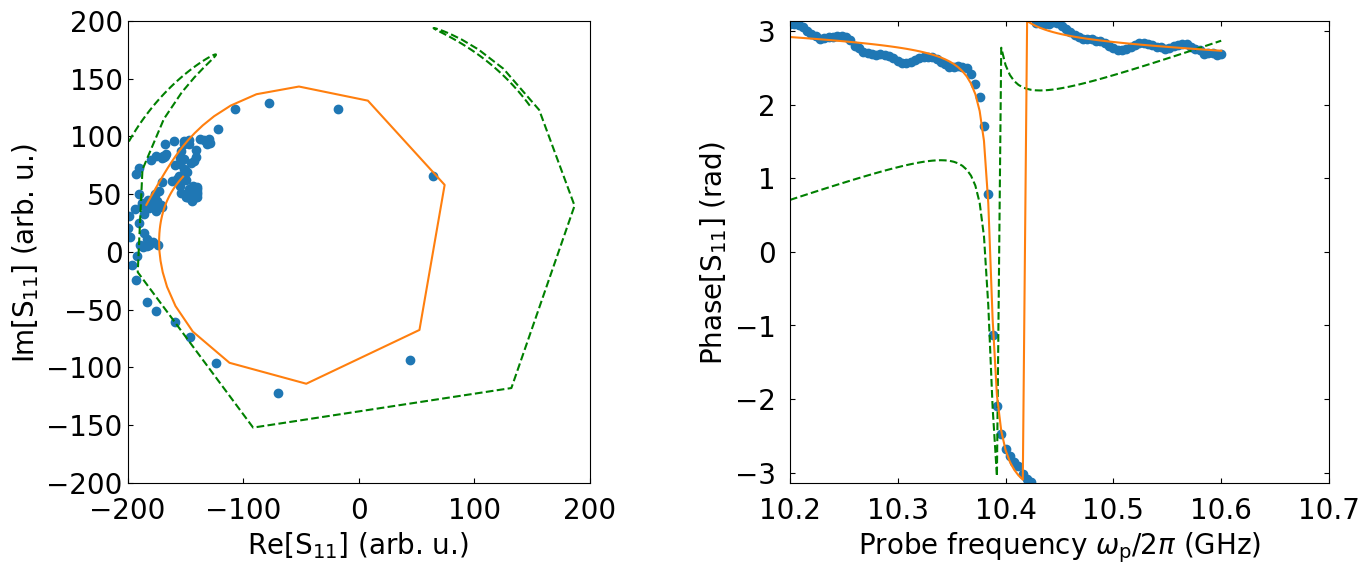

In [121]:
res = model.fit(data = s11_g, params = params, freq = freq)

fig, ax = plt.subplots(1, 2, figsize=(16,6))#,constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.subplots_adjust(wspace=0.3)
plt.tick_params(pad = 10, top='on',bottom='on',left='on',right='on',)
ax[0].set_aspect("equal", adjustable="box")
ax[0].set_xlabel('Re[S$_{11}$] (arb. u.) ')
ax[0].set_ylabel('Im[S$_{11}$] (arb. u.) ')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_xlim(-200, 200)
ax[0].set_ylim(-200, 200)
ax[0].get_xaxis().set_tick_params(pad=10)

ax[1].set_xlabel('Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)')
ax[1].set_ylabel('Phase[S$_{11}$] (rad) ')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_xlim(10.2, 10.7)
ax[1].set_ylim(-np.pi, np.pi)


ax[0].plot(np.real(s11_g),np.imag(s11_g) , ls='', marker='o')
ax[0].plot(np.real(res.init_fit), np.imag(res.init_fit), '--', label='initial fit', color='green')
ax[0].plot(np.real(res.best_fit), np.imag(res.best_fit))
ax[1].plot(freq*1e-9, np.angle(s11_g),  ls='', marker='o')
ax[1].plot(freq*1e-9, np.angle(res.init_fit), '--', label='initial fit', color='green')
ax[1].plot(freq*1e-9, np.angle(res.best_fit))
# plt.savefig('chi_g.png', bbox_inches='tight')
plt.show()
res

In [ ]:
par_ini = {'fr': 9.38e9,  'ff': 9.4e9,    'kf_e': 108e6,   'kf_i': 0.e6,  'g': 45e6, 'gamma': 0.e6,
           'a0': 50,  'a1': 3.5e-7	,        'Poff': -19575,   'ed': 6e-12}
par_min = {'fr': 0,     'ff': 0,        'kf_e': 0,        'kf_i': 0,        'g': 0,     'gamma': 0,
           'a0': -np.inf,     'a1': -np.inf,  'Poff': -np.inf,'ed': -np.inf}
par_max = {'fr': np.inf,'ff': np.inf,   'kf_e': np.inf,   'kf_i': np.inf,   'g': np.inf,'gamma': np.inf,
           'a0': np.inf,'a1': np.inf,   'Poff': np.inf, 'ed': np.inf}
par_var = {'fr': True, 'ff': True,    'kf_e': True,    'kf_i': False,    'g': True, 'gamma': False,
           'a0': True, 'a1': True,    'Poff': True,  'ed':  True}

model=lmfit.Model(S11_dpr_model)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
for name in list(par_min):
    params[name].set(min=par_min[name])  
for name in list(par_max):
    params[name].set(max=par_max[name]) 
for name in list(par_var):
    params[name].set(vary=par_var[name])

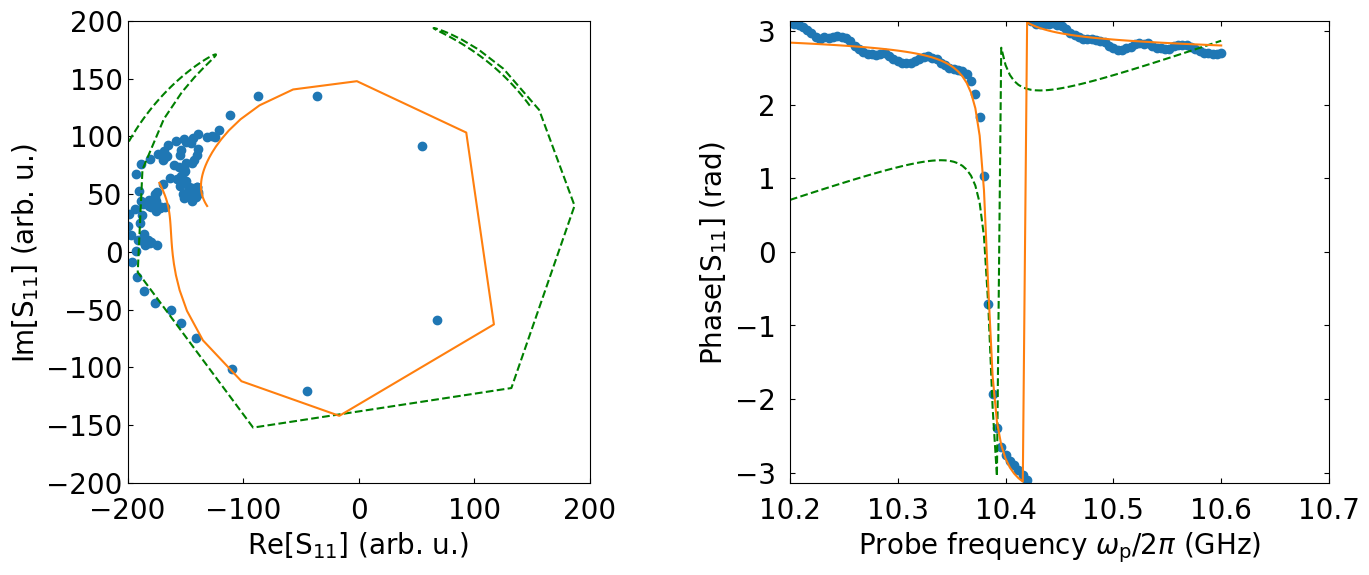

In [122]:
res = model.fit(data = s11_e, params = params, freq = freq, method='nelder')

fig, ax = plt.subplots(1, 2, figsize=(16,6))#,constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.subplots_adjust(wspace=0.3)
plt.tick_params(pad = 10, top='on',bottom='on',left='on',right='on',)
ax[0].set_aspect("equal", adjustable="box")
ax[0].set_xlabel('Re[S$_{11}$] (arb. u.) ')
ax[0].set_ylabel('Im[S$_{11}$] (arb. u.) ')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_xlim(-200, 200)
ax[0].set_ylim(-200, 200)
ax[0].get_xaxis().set_tick_params(pad=10)

ax[1].set_xlabel('Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)')
ax[1].set_ylabel('Phase[S$_{11}$] (rad) ')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_xlim(10.2, 10.7)
ax[1].set_ylim(-np.pi, np.pi)

ax[0].plot(np.real(s11_e), np.imag(s11_e),  ls='', marker='o')
# ax[0].plot(x, np.real(s11_e),'.', color='k')
ax[0].plot(np.real(res.init_fit), np.imag(res.init_fit),'--', label='initial fit', color='green')
# ax[0].plot(np.real(res.best_fit),np.imag(res.best_fit), '-', label='best fit', color='red')
ax[0].plot(np.real(res.best_fit), np.imag(res.best_fit))
ax[1].plot(freq*1e-9, np.angle(s11_e),  ls='', marker='o')
ax[1].plot(freq*1e-9, np.angle(res.init_fit), '--', label='initial fit', color='green')
ax[1].plot(freq*1e-9, np.angle(res.best_fit))
# plt.savefig('chi_e.png', bbox_inches='tight')
plt.show()
res

In [123]:
(10.383-10.387)/2

-0.002000000000000668

In [ ]:
f_hg = 9.3951e9
f_lg = 9.3766e9
f_he = 9.3946e9
f_le = 9.3704e9

chi_l = (f_le - f_lg)/2
chi_h = (f_he - f_hg)/2 
chi = chi_l
chi

-3100000.0

Compute hybolidized mode

In [4]:
import numpy as np
def compute_eigenmodes(omega_r_ge, omega_p, kappa_p, J):
    """
    omega_r_ge: float - resonator frequency depending on qubit state (Hz)
    omega_p: float - another mode or drive frequency (Hz)
    kappa_p: float - decay rate of mode p (Hz)
    J: float - coupling strength between modes (Hz)
    """
    delta_rp = omega_r_ge - omega_p
    complex_term = (delta_rp + 1j * kappa_p / 2)**2 + (2 * J)**2
    sqrt_term = np.sqrt(complex_term)
    
    omega_avg = 0.5 * (omega_r_ge + omega_p)
    omega_l = omega_avg - 0.5 * sqrt_term.real
    omega_h = omega_avg + 0.5 * sqrt_term.real
    
    return {
        "omega_l": omega_l,
        "omega_h": omega_h
    }

In [5]:
# BW9500 from CDK183
params = {
    "omega_r_ge": 9.346e9,  # Hz
    "omega_p": 9.340e9,     # Hz
    "kappa_p": 141e6,       # Hz
    "J": 	59e6             # Hz
}

results = compute_eigenmodes(**params)
print(f"ω_l: {results['omega_l'] / 1e9:.6f} GHz")
print(f"ω_h: {results['omega_h'] / 1e9:.6f} GHz")

ω_l: 9.295541 GHz
ω_h: 9.390459 GHz


# reset

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

from sequence_parser import Sequence, Variable, Variables
from sequence_parser.iq_port import Port
from sequence_parser.instruction import *

In [13]:
import sklearn
from sklearn.decomposition import PCA

In [14]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

## active reset
ef freq

In [15]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

-0.38


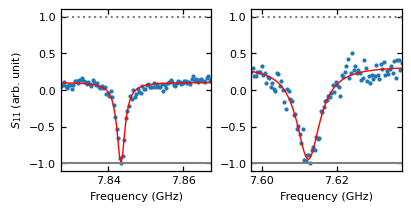

In [17]:


header = "C:/Users/qipe/Documents/K_Sunada/result/CDK184/"
ef_freq_tx = "/2025-08-11/2025-08-11T190836_253b6885-f0_active_reset_ef_freq"
dd_tx = datadict_from_hdf5(header + ef_freq_tx +"/data")

S11_tx = dd_tx['s11']['values']
freq_tx = dd_tx['anhm']['values']
S11_PCA_tx = PCA_transform(S11_tx.real, S11_tx.imag)[0]

par_ini = {'amp': 6e-04,'const':-2e-5,'center':-0.368,'k':0.005}
par_min = {'amp': 0,'const':-np.inf,'center':-np.inf,'k':0}
par_max = {'amp': np.inf,'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True,'center':True,'k':True}

model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
result_tx = model.fit(data = -S11_PCA_tx, params = params, freq = freq_tx)

ef_freq_rx = "/2025-08-12/2025-08-12T082918_00591c26-f0_active_reset_ef_freq"
dd_rx = datadict_from_hdf5(header + ef_freq_rx +"/data")

S11_rx = dd_rx['s11']['values']
freq_rx = dd_rx['anhm']['values']
S11_PCA_rx = PCA_transform(S11_rx.real, S11_rx.imag)[0]

par_ini = {'amp': 1.5e-04,'const':-2e-5,'center':-0.365,'k':0.005}
par_min = {'amp': 0,'const':-np.inf,'center':-np.inf,'k':0}
par_max = {'amp': np.inf,'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True,'center':True,'k':True}

model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
result_rx = model.fit(data = S11_PCA_rx, params = params, freq = freq_rx)


fig, ax = plt.subplots(1, 2, figsize=(4,2), constrained_layout=True)

# plt.title("g-e transition")
ax[0].tick_params(axis="both", direction="in")
ax[0].tick_params(top=True, bottom=True, left=True, right=True)
ax[1].tick_params(axis="both", direction="in")
ax[1].tick_params(top=True, bottom=True, left=True, right=True)
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
ge_freq_tx =  8.207+0.000405764-1.388e-05-1.684e-05+4.0565e-05
ge_freq_rx = 7.976+0.001277485-2.569e-05
ax[0].plot(ge_freq_tx+freq_tx, -S11_PCA_tx/np.max(S11_PCA_tx), 'o')
ax[0].plot(ge_freq_tx+freq_tx, result_tx.best_fit/np.max(S11_PCA_tx), c="red", lw=1.0)
ax[0].set_xlabel("Frequency (GHz)")
ax[0].set_ylabel(r"$S_{11}$ (arb. unit)")
ax[0].set_xlim(ge_freq_tx+freq_tx[0], ge_freq_tx+freq_tx[-1])
ax[0].axhline(y=1, color="gray", linestyle=":", linewidth=1.5)
ax[0].axhline(y=-1, color="gray", linewidth=1.5)


ax[1].plot(ge_freq_rx+freq_rx, -S11_PCA_rx/np.min(S11_PCA_rx), 'o')
ax[1].plot(ge_freq_rx+freq_rx, -result_rx.best_fit/np.min(S11_PCA_rx), c="red", lw=1.0)
ax[1].set_xlabel("Frequency (GHz)")
# ax[1].set_ylabel(r"$S_{11}$ (arb. unit)")
ax[1].set_xlim(ge_freq_rx+freq_rx[0], ge_freq_rx+freq_rx[-1])
ax[1].axhline(y=1, color="gray", linestyle=":", linewidth=1.5)
ax[1].axhline(y=-1, color="gray", linewidth=1.5)

print(freq_rx[0])
plt.savefig("mas_figs/reset_freq.pdf",  bbox_inches="tight")
plt.show()


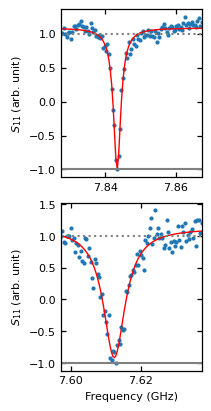

In [19]:
def rescale_pm1(x):
    """Rescale array so that max → 1, min → -1."""
    x_min = np.min(x)
    x_max = x[0]
    return 2 * (x - x_min) / (x_max - x_min) - 1

def rescale_pm12(x):
    """Rescale array so that max → 1, min → -1."""
    x_min = x[0]
    x_max = np.max(x)
    return 2 * (x - x_min) / (x_max - x_min) - 1

header = "C:/Users/qipe/Documents/K_Sunada/result/CDK184/"


# ---------------------------
# TX data
# ---------------------------
ef_freq_tx = "/2025-08-11/2025-08-11T190836_253b6885-f0_active_reset_ef_freq"
dd_tx = datadict_from_hdf5(header + ef_freq_tx + "/data")

S11_tx = dd_tx['s11']['values']
freq_tx = dd_tx['anhm']['values']
S11_PCA_tx = PCA_transform(S11_tx.real, S11_tx.imag)[0]

# --- rescale ---
S11_tx_scaled = rescale_pm12(S11_PCA_tx)

# --- fitting ---
par_ini = {'amp': 0.5, 'const': 0.0, 'center': -0.368, 'k': 0.005}
par_min = {'amp': 0, 'const': -np.inf, 'center': -np.inf, 'k': 0}
par_max = {'amp': np.inf, 'const': np.inf, 'center': np.inf, 'k': np.inf}
par_vary = {'amp': True, 'const': True, 'center': True, 'k': True}

model = lmfit.Model(Lorentzian)
params = model.make_params()

for name in model.param_names:
    params[name].set(value=par_ini[name],
                     min=par_min[name],
                     max=par_max[name],
                     vary=par_vary[name])

result_tx = model.fit(data=-S11_tx_scaled, params=params, freq=freq_tx)


# ---------------------------
# RX data
# ---------------------------
ef_freq_rx = "/2025-08-12/2025-08-12T082918_00591c26-f0_active_reset_ef_freq"
dd_rx = datadict_from_hdf5(header + ef_freq_rx + "/data")

S11_rx = dd_rx['s11']['values']
freq_rx = dd_rx['anhm']['values']
S11_PCA_rx = PCA_transform(S11_rx.real, S11_rx.imag)[0]

# --- rescale ---
S11_rx_scaled = rescale_pm1(S11_PCA_rx)

# --- fitting ---
par_ini = {'amp': 0.5, 'const': 0.0, 'center': -0.365, 'k': 0.005}

model = lmfit.Model(Lorentzian)
params = model.make_params()

for name in model.param_names:
    params[name].set(value=par_ini[name],
                     min=par_min[name],
                     max=par_max[name],
                     vary=par_vary[name])

result_rx = model.fit(data=S11_rx_scaled, params=params, freq=freq_rx)


# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(2, 1, figsize=(2, 4), constrained_layout=True)

for a in ax:
    a.tick_params(axis="both", direction="in")
    a.tick_params(top=True, bottom=True, left=True, right=True)

plt.rcParams['xtick.major.width'] = 0.9
plt.rcParams['ytick.major.width'] = 0.9
plt.rcParams['font.size'] = 8
plt.rcParams['axes.linewidth'] = 0.9
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2

ge_freq_tx = 8.207 + 0.000405764 - 1.388e-05 - 1.684e-05 + 4.0565e-05
ge_freq_rx = 7.976 + 0.001277485 - 2.569e-05

# TX plot
ax[0].plot(ge_freq_tx + freq_tx, -S11_tx_scaled, 'o')
ax[0].plot(ge_freq_tx + freq_tx, result_tx.best_fit, c="red", lw=1.0)

ax[0].set_ylabel(r"$S_{11}$ (arb. unit)")
ax[0].set_xlim(ge_freq_tx + freq_tx[0], ge_freq_tx + freq_tx[-1])
ax[0].axhline(y=1, color="gray", linestyle=":", linewidth=1.5)
ax[0].axhline(y=-1, color="gray", linewidth=1.5)

# RX plot
ax[1].plot(ge_freq_rx + freq_rx, S11_rx_scaled, 'o')
ax[1].plot(ge_freq_rx + freq_rx, result_rx.best_fit, c="red", lw=1.0)
ax[1].set_xlabel("Frequency (GHz)")
ax[1].set_ylabel(r"$S_{11}$ (arb. unit)")
ax[1].set_xlim(ge_freq_rx + freq_rx[0], ge_freq_rx + freq_rx[-1])
ax[1].axhline(y=1, color="gray", linestyle=":", linewidth=1.5)
ax[1].axhline(y=-1, color="gray", linewidth=1.5)

plt.savefig("mas_figs/reset_freq.pdf", bbox_inches="tight")
plt.show()


ef amplitude

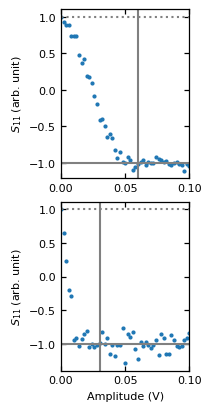

In [63]:
def rescale_pm1(x):
    """Rescale array so that max→1, min→-1"""
    x_min = np.mean(x[30::])
    x_max = np.max(x)
    return 2 * (x - x_min) / (x_max - x_min) - 1


ef_amp_tx = "/2025-08-11/2025-08-11T191004_59960af5-f1_active_reset_ef_amp"
dd_tx = datadict_from_hdf5(header + ef_amp_tx + "/data")

S11_tx = dd_tx['s11']['values']
freq_tx = dd_tx['amplitude']['values']
S11_PCA_tx = -PCA_transform(S11_tx.real, S11_tx.imag)[0]

# ---- ★ rescale ----
S11_tx_scaled = rescale_pm1(S11_PCA_tx)


ef_amp_rx = "/2025-08-12/2025-08-12T083036_2f34e9ec-f1_active_reset_ef_amp"
dd_rx = datadict_from_hdf5(header + ef_amp_rx + "/data")

S11_rx = dd_rx['s11']['values']
freq_rx = dd_rx['amplitude']['values']
S11_PCA_rx = PCA_transform(S11_rx.real, S11_rx.imag)[0]

# ---- ★ rescale ----
S11_rx_scaled = rescale_pm1(S11_PCA_rx)


fig, ax = plt.subplots(2, 1, figsize=(2,4), constrained_layout=True)

ax[0].tick_params(axis="both", direction="in")
ax[0].tick_params(top=True, bottom=True, left=True, right=True)
ax[1].tick_params(axis="both", direction="in")
ax[1].tick_params(top=True, bottom=True, left=True, right=True)

plt.rcParams['xtick.major.width'] = 0.9
plt.rcParams['ytick.major.width'] = 0.9
plt.rcParams['font.size'] = 8
plt.rcParams['axes.linewidth'] = 0.9
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2

ax[0].plot(freq_tx, S11_tx_scaled, 'o')

ax[0].set_ylabel(r"$S_{11}$ (arb. unit)")
ax[0].set_xlim(freq_tx[0], freq_tx[-1])
ax[0].axhline(y=1, color="gray", linestyle=":", linewidth=1.5)
ax[0].axhline(y=-1, color="gray",  linewidth=1.5)

ax[1].plot(freq_rx, S11_rx_scaled, 'o')
ax[1].set_xlabel("Amplitude (V)")
ax[1].set_ylabel(r"$S_{11}$ (arb. unit)")
ax[1].set_xlim(freq_rx[0], freq_rx[-1])
ax[1].axhline(y=1, color="gray", linestyle=":", linewidth=1.5)
ax[1].axhline(y=-1, color="gray",  linewidth=1.5)
ax[0].axvline(0.06, color="gray", linewidth=1.5)
ax[1].axvline(0.03, color="gray", linewidth=1.5)
plt.savefig("mas_figs/reset_amp.pdf",  bbox_inches="tight")
plt.show()


In [ ]:
def cos(x, amp, freq, phi, const):
    return amp * np.cos(2*np.pi*x*freq+phi) + const

In [ ]:
par_ini= {'amp': 0.0005,'freq':1/0.01,'phi':0,'const':0}
par_min= {'amp': 0,'freq':0,'phi':-2*np.pi,'const':-np.inf}
par_max= {'amp': np.inf,'freq':np.inf,'phi':2*np.pi,'const':np.inf}
par_vary= {'amp': True,'freq': True,'phi': True,'const': True}

model = lmfit.Model(cos)

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
result = model.fit(data = -S11_PCA, params = params, x = freq)
result

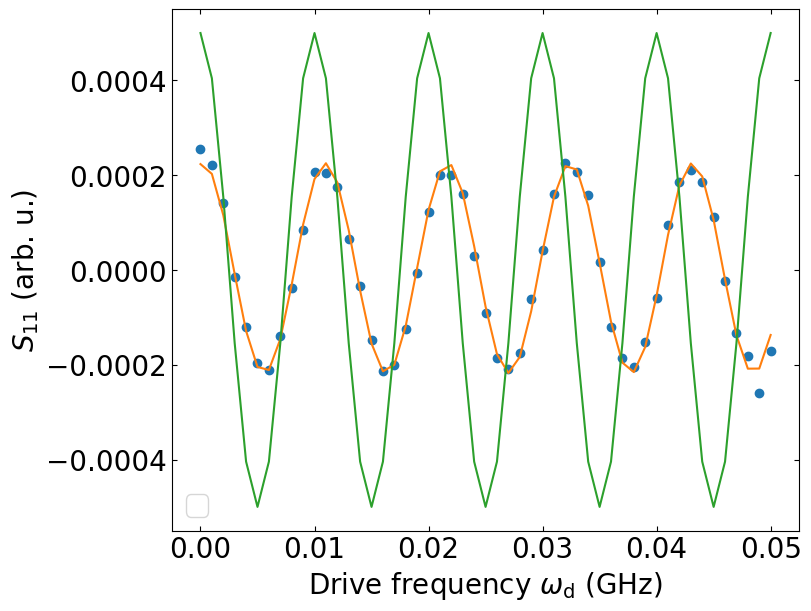

In [ ]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(freq, result.init_fit)
# plt.xlim(7.95, 8.065)

plt.title("")
plt.legend("")
plt.xlabel("Drive frequency $\omega_\mathrm{d}$ (GHz)")
plt.ylabel("$S_{11}$ (arb. u.)")
# plt.savefig('ge_peak.png', bbox_inches='tight')
plt.show()

In [ ]:
(np.pi+0.13020050)/(2*np.pi*93.2168900)

0.0055861341562461085

## FFT

In [ ]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [ ]:
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

## 10/13 photon shape & photon number

In [ ]:
header = "D:/K_sunada/result/CDY168/"
atten = -105.96 #dBm

In [ ]:
from scipy.constants import *

In [ ]:
def watt_dbm(watt):
    return 10*np.log10(watt*1e3)

def dbm_watt(dBm):
    return (10**(dBm/10))*1e-3

In [ ]:
def photon_number(pulse, freq, atten, sample_rate):
    #pulse: [x, y, env], atten: dBm, samplerate: s, P_vna: W (AWG amp=1.0)
    x = pulse[0]
    y = pulse[2] #env

    atten_W = dbm_watt(atten)
    ene = 0
    for t in range(int(len(x)/2)):
        ene = ene + (y[2*t]**2)*sample_rate

    return ene * atten_W / (2*np.pi*hbar*freq)


## Photon shape

In [ ]:
readout_lo_freq = 9.5e9
target_freq = 9.35e9
ph_if = readout_lo_freq - target_freq
duration = 1000
const = 2.5e-3 * 2 * np.pi
sample_rate = 2e-9
amp = 0.07

0.010025321596313717

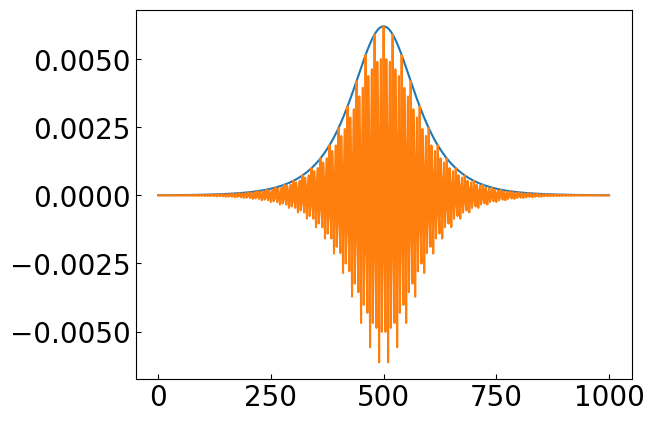

In [ ]:
## sech_0
x = np.arange(0, 1001, 2)
y_env = (const/2)**0.5/np.cosh(const * (x - duration/2)) * amp
y = (const/2)**0.5/np.cosh(const * (x - duration/2))*np.cos(2*np.pi* ph_if*x*1e-9) * amp
plt.plot(x, y_env)
plt.plot(x, y)

pulse = [x, y, y_env]
photon_number(pulse, target_freq, atten, sample_rate)

0.020365318460978967

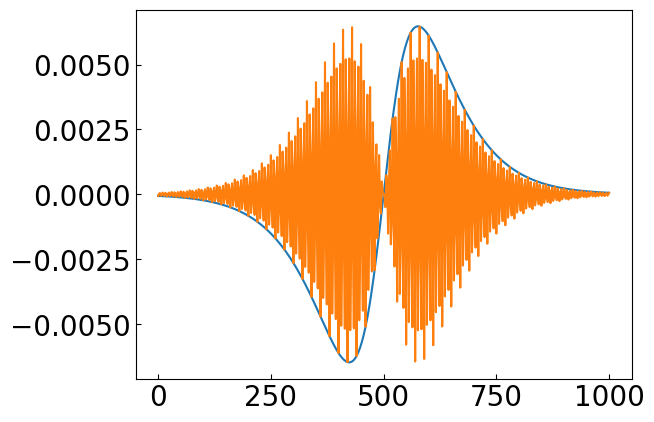

In [ ]:
## sech_1
y_env = (6*const**3/(np.pi**2))**0.5*(x - duration/2)/np.cosh(const * (x - duration/2)) * amp
y = (6*const**3/(np.pi**2))**0.5*(x - duration/2)/np.cosh(const * (x - duration/2))*np.cos(2*np.pi* ph_if*x*1e-9) * amp
plt.plot(x, y_env)
plt.plot(x, y)


pulse = [x, y, y_env]
photon_number(pulse, target_freq, atten, sample_rate)

0.020352022707611432

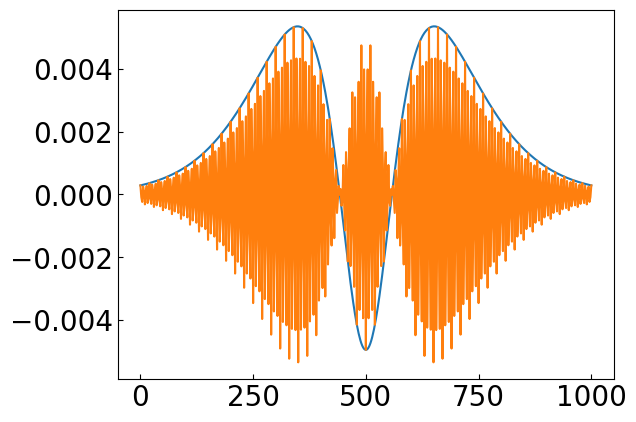

In [ ]:
## sech_2
y_env = (45*(2*const)**5/64/(np.pi**4))**0.5*((x - duration/2)**2-(np.pi/2/const)**2/3)/np.cosh(const * (x - duration/2)) * amp
y = (45*(2*const)**5/64/(np.pi**4))**0.5*((x - duration/2)**2-(np.pi/2/const)**2/3)/np.cosh(const * (x - duration/2))*np.cos(2*np.pi* ph_if*x*1e-9) * amp
plt.plot(x, y_env)
plt.plot(x, y)


pulse = [x, y, y_env]
photon_number(pulse, target_freq, atten, sample_rate)

0.020202799427517626

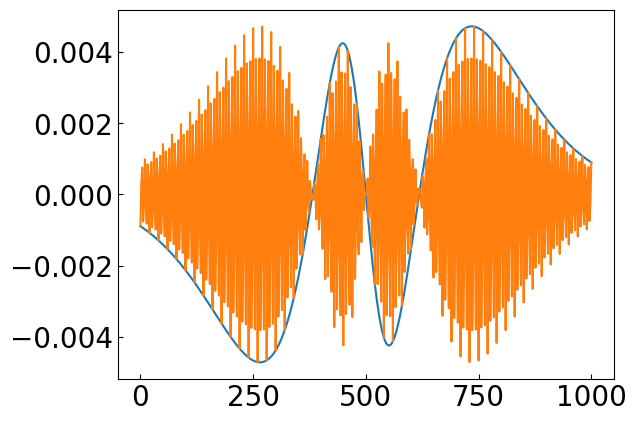

In [ ]:
## sech_3
y_env = (175*(2*const)**7)**0.5/24/(np.pi**3)*((x - duration/2)**3-(7*(x - duration/2)*(np.pi/(2*const))**2/5))/np.cosh(const * (x - duration/2)) * amp
y = (175*(2*const)**7)**0.5/24/(np.pi**3)*((x - duration/2)**3-(7*(x - duration/2)*(np.pi/(2*const))**2/5))/np.cosh(const * (x - duration/2))*np.cos(2*np.pi* ph_if*x*1e-9) * amp
plt.plot(x, y_env)
plt.plot(x, y)


pulse = [x, y, y_env]
photon_number(pulse, target_freq, atten, sample_rate)

0.03352424221193056

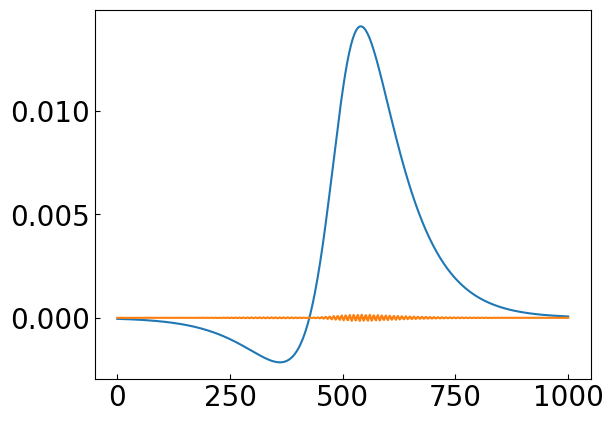

In [ ]:

amp = 0.011

y_env0 = 1/np.cosh(const * (x - duration/2))
y_env1 = (x - duration/2)/np.cosh(const * (x - duration/2)) 
m = sum(np.abs(y_env0))/sum(np.abs(y_env1))
y_env = (y_env0 + y_env1*m)* amp
y = y_env*np.cos(2*np.pi* ph_if*x*1e-9) * amp
plt.plot(x, y_env)
plt.plot(x, y)


pulse = [x, y, y_env]
photon_number(pulse, target_freq, atten, sample_rate)